# PARALLEL_PARC Data Exploration & Analysis

**Objective**: Comprehensive exploration of the PARALLEL_PARC dataset to understand analogy patterns, domain relationships, and extract actionable insights for improving analogy generation models.

**Key Questions**:
- Which domains work best as sources?
- What characterizes high-quality analogies?
- How do close vs far analogies differ?
- What patterns exist in mappings and relations?
- Which source concepts are most versatile?

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter, defaultdict
import warnings

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")



Libraries imported successfully!


In [2]:
# Load the PARALLEL_PARC dataset
df = pd.read_csv('parallel_parc.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully!
Shape: 310 rows × 13 columns

Column names:
['Unnamed: 0', 'sample_id', 'source_id', 'source_subject', 'source_domain', 'target_domain', 'target_subject', 'target_field', 'relations', 'source_paragraph', 'target_paragraph', 'analogy_type', 'sum_vote_analogy']


,Unnamed: 0,sample_id,source_id,source_subject,source_domain,target_domain,target_subject,target_field,relations,source_paragraph,target_paragraph,analogy_type,sum_vote_analogy
0,1,7What causes a boiler to explode?,7,What causs a volcano to erupt?,Natural Sciences,Engineering,What causes a boiler to explode?,Chemical Engineering,"(magma, heats, underground water) like (steam,...","When magma heats up underground water, pressur...","Steam heats the liquid inside the boiler, caus...",far analogy,3.0
1,3,7What causes an earthquake to occur?,7,What causs a volcano to erupt?,Natural Sciences,Natural Sciences,What causes an earthquake to occur?,Earth Sciences,"(magma, builds up, pressure) like (tectonic pl...",A volcano erupts when magma builds up pressure...,An earthquake is caused by the tension that bu...,close analogy,3.0
2,6,7How does a political system change over time?,7,What causs a volcano to erupt?,Natural Sciences,Social Sciences,How does a political system change over time?,Political Science,"(tectonic plates, shift, Earth's crust) like (...",Volcanic eruptions occur when tectonic plates ...,"Ideas shift public opinion, which can lead to ...",far analogy,3.0
3,10,7What causes an autoimmune disease to flare up?,7,What causs a volcano to erupt?,Natural Sciences,Biomedical and Health Sciences,What causes an autoimmune disease to flare up?,Biomedical and Health Sciences,"(magma, builds up, pressure) like (antigens, b...",Volcanic eruptions are caused by the buildup o...,An autoimmune disease is caused by an overreac...,far analogy,3.0
4,12,11How does a river erode its banks?,11,What happens during erosion by the ocean?,Natural Sciences,Engineering,How does a river erode its banks?,Civil Engineering,"(ocean waves, wash away, rocks and sand) like ...",Ocean waves wash away rocks and sand.\n Tides ...,The river flow washes away soil and sediment f...,close analogy,3.0


## 1. Data Loading & Quality Assessment

Understanding the dataset structure and check for any data quality issues.


In [3]:
# Check data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*80 + "\n")

# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("No missing values found!")
    
print("\n" + "="*80 + "\n")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

print("\n" + "="*80 + "\n")

# Basic statistics
print("Dataset Statistics:")
print(df.describe(include='all'))


Data Types:
Unnamed: 0            int64
sample_id            object
source_id             int64
source_subject       object
source_domain        object
target_domain        object
target_subject       object
target_field         object
relations            object
source_paragraph     object
target_paragraph     object
analogy_type         object
sum_vote_analogy    float64
dtype: object


Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []
No missing values found!


Duplicate rows: 0


Dataset Statistics:
         Unnamed: 0                          sample_id    source_id  \
count    310.000000                                310   310.000000   
unique          NaN                                310          NaN   
top             NaN  7What causes a boiler to explode?          NaN   
freq            NaN                                  1          NaN   
mean    1810.229032                                NaN   584.832258   
std     1325.581358                 

## 2. Domain Analysis

Understanding domain distributions and cross-domain patterns is crucial for analogy generation.


Source Domain Distribution:
source_domain
Natural Sciences                  180
Biomedical and Health Sciences     72
Engineering                        57
Social Sciences                     1
Name: count, dtype: int64

Unique source domains: 4


Target Domain Distribution:
target_domain
Natural Sciences                  123
Engineering                        77
Social Sciences                    56
Biomedical and Health Sciences     54
Name: count, dtype: int64

Unique target domains: 4


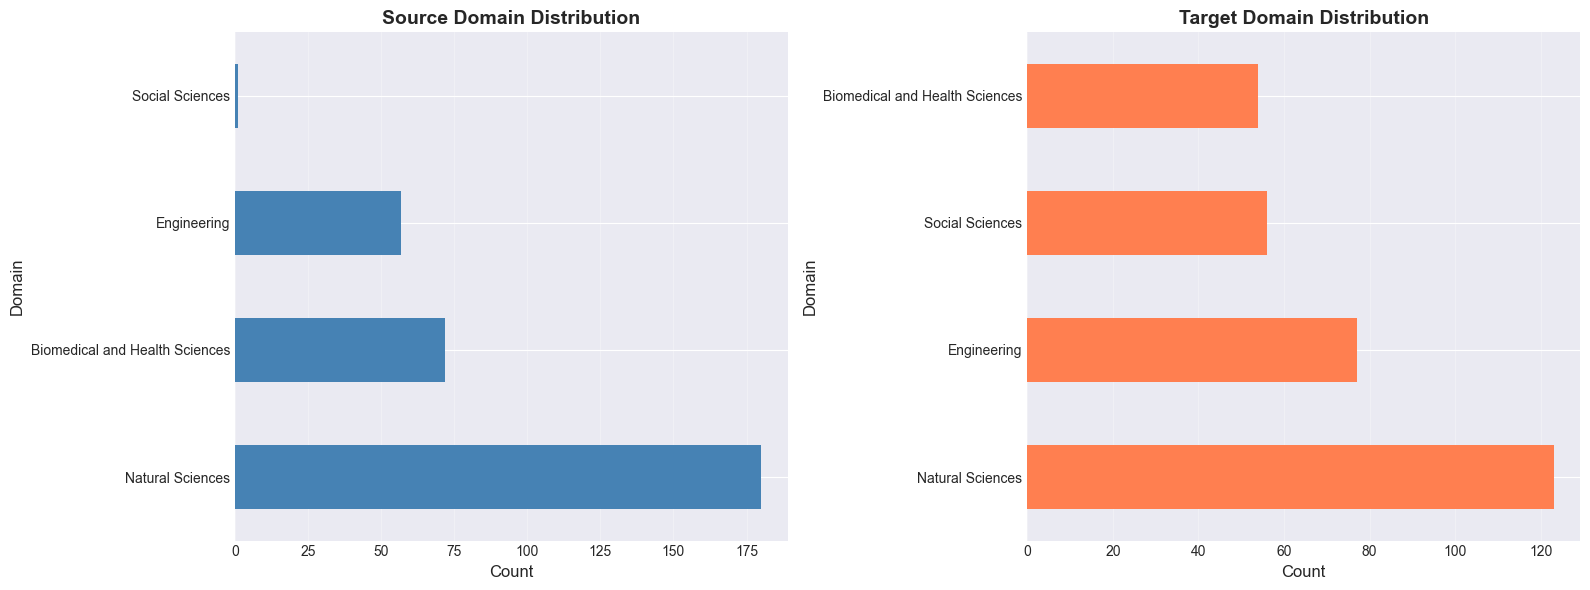

In [4]:
# Domain distributions
print("Source Domain Distribution:")
source_domains = df['source_domain'].value_counts()
print(source_domains)
print(f"\nUnique source domains: {df['source_domain'].nunique()}")

print("\n" + "="*80 + "\n")

print("Target Domain Distribution:")
target_domains = df['target_domain'].value_counts()
print(target_domains)
print(f"\nUnique target domains: {df['target_domain'].nunique()}")

# Visualization: Domain distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Source domains
source_domains.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Source Domain Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Domain', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Target domains
target_domains.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Target Domain Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Domain', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Top 20 Domain Pairs (Source → Target):
                     source_domain                   target_domain  count
10                Natural Sciences                Natural Sciences     77
9                 Natural Sciences                     Engineering     40
11                Natural Sciences                 Social Sciences     37
8                 Natural Sciences  Biomedical and Health Sciences     26
2   Biomedical and Health Sciences                Natural Sciences     24
6                      Engineering                Natural Sciences     22
0   Biomedical and Health Sciences  Biomedical and Health Sciences     20
1   Biomedical and Health Sciences                     Engineering     19
5                      Engineering                     Engineering     17
7                      Engineering                 Social Sciences     10
3   Biomedical and Health Sciences                 Social Sciences      9
4                      Engineering  Biomedical and Health Sciences      8

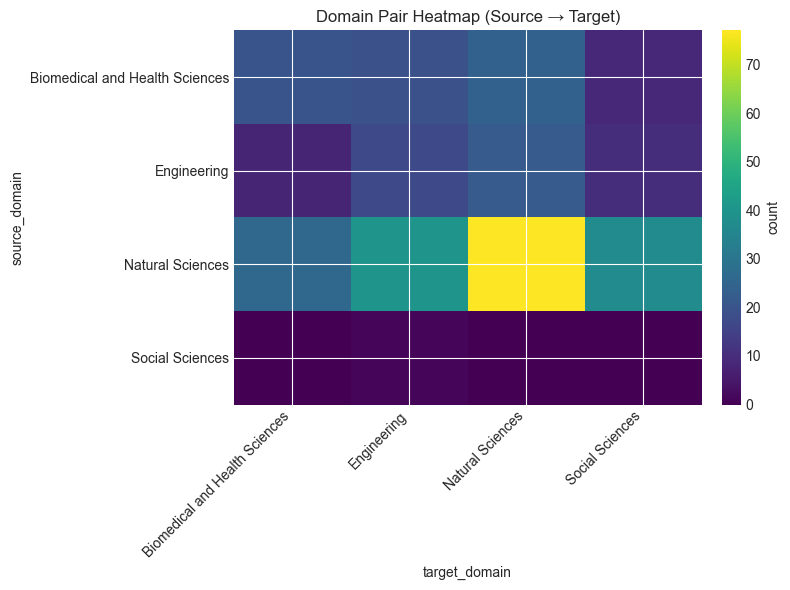

In [5]:
# Cross-domain mapping analysis
domain_pairs = df.groupby(['source_domain', 'target_domain']).size().reset_index(name='count')
domain_pairs_sorted = domain_pairs.sort_values('count', ascending=False)

print("Top 20 Domain Pairs (Source → Target):")
print(domain_pairs_sorted.head(20))

print("\n" + "="*80 + "\n")

# Check within-domain vs cross-domain
df['same_domain'] = df['source_domain'] == df['target_domain']
within_domain = df['same_domain'].sum()
cross_domain = (~df['same_domain']).sum()

print(f"Within-domain analogies: {within_domain} ({within_domain/len(df)*100:.1f}%)")
print(f"Cross-domain analogies: {cross_domain} ({cross_domain/len(df)*100:.1f}%)")

# Create domain pair heatmap
heat = domain_pairs.pivot(index='source_domain', columns='target_domain', values='count').fillna(0)

plt.figure(figsize=(max(8, heat.shape[1]*0.6), max(6, heat.shape[0]*0.5)))
im = plt.imshow(heat.values, aspect="auto", cmap='viridis')
plt.title("Domain Pair Heatmap (Source → Target)")
plt.xlabel("target_domain")
plt.ylabel("source_domain")

plt.xticks(range(heat.shape[1]), heat.columns.astype(str), rotation=45, ha="right")
plt.yticks(range(heat.shape[0]), heat.index.astype(str))

plt.colorbar(im, fraction=0.046, pad=0.04, label="count")
plt.tight_layout()
plt.show()


## 3. Analogy Type Patterns

Exploring the relationship between "close" vs "far" analogies and domain transitions.


Analogy Type Distribution:
analogy_type
close analogy    186
far analogy      124
Name: count, dtype: int64

Close analogies: 186 (60.0%)
Far analogies: 124 (40.0%)


Analogy Type by Domain Relationship:
same_domain       False      True
analogy_type                     
close analogy  0.392473  0.607527
far analogy    0.991935  0.008065
All            0.632258  0.367742


Percentage breakdown (row-wise):
same_domain    False  True 
analogy_type               
close analogy   39.2   60.8
far analogy     99.2    0.8


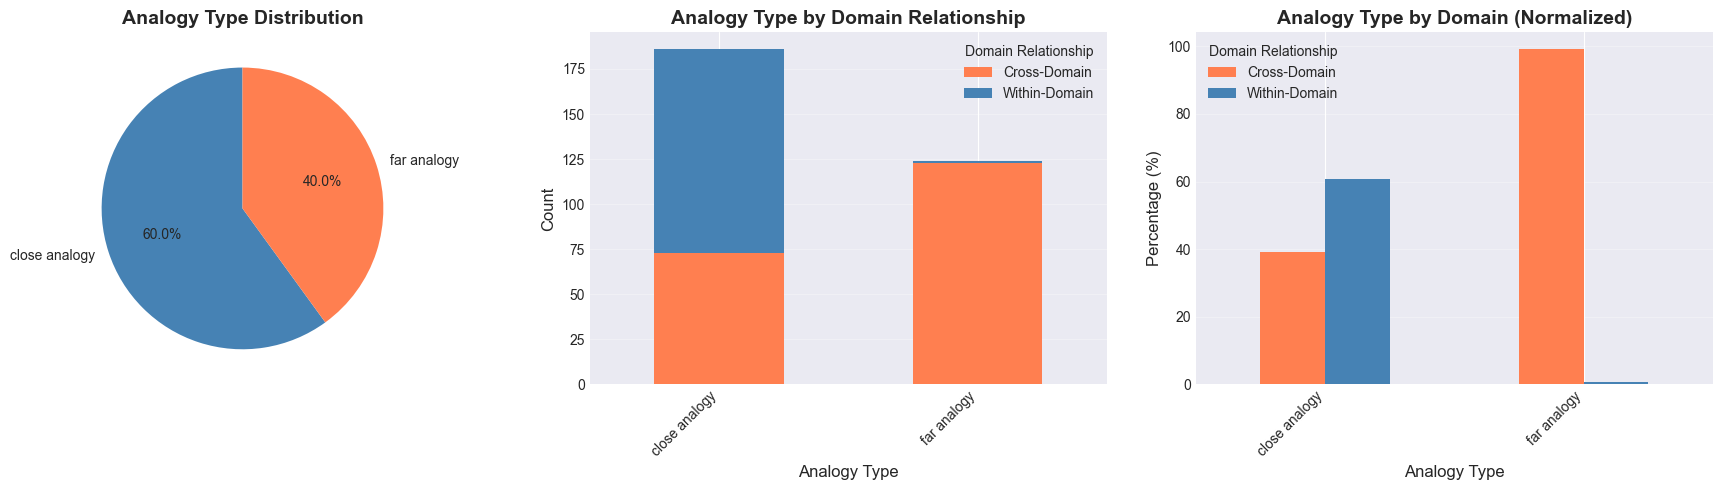

In [6]:
# Analogy type distribution
print("Analogy Type Distribution:")
analogy_type_dist = df['analogy_type'].value_counts()
print(analogy_type_dist)
print(f"\nClose analogies: {analogy_type_dist.get('close analogy', 0)} ({analogy_type_dist.get('close analogy', 0)/len(df)*100:.1f}%)")
print(f"Far analogies: {analogy_type_dist.get('far analogy', 0)} ({analogy_type_dist.get('far analogy', 0)/len(df)*100:.1f}%)")

# Relationship between analogy type and domain similarity
print("\n" + "="*80 + "\n")
print("Analogy Type by Domain Relationship:")
cross_tab = pd.crosstab(df['analogy_type'], df['same_domain'], margins=True, normalize='index')
print(cross_tab)

print("\n" + "="*80 + "\n")

# Percentage breakdown
analogy_domain_cross = pd.crosstab(df['analogy_type'], df['same_domain'], normalize='index') * 100
print("Percentage breakdown (row-wise):")
print(analogy_domain_cross.round(1))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart of analogy types
colors = ['steelblue', 'coral']
analogy_type_dist.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Analogy Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Stacked bar chart
analogy_domain_df = pd.crosstab(df['analogy_type'], df['same_domain'])
analogy_domain_df.columns = ['Cross-Domain', 'Within-Domain']
analogy_domain_df.plot(kind='bar', stacked=True, ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_title('Analogy Type by Domain Relationship', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Analogy Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Domain Relationship')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Grouped bar chart (normalized)
analogy_domain_pct = pd.crosstab(df['analogy_type'], df['same_domain'], normalize='index') * 100
analogy_domain_pct.columns = ['Cross-Domain', 'Within-Domain']
analogy_domain_pct.plot(kind='bar', ax=axes[2], color=['coral', 'steelblue'])
axes[2].set_title('Analogy Type by Domain (Normalized)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Analogy Type', fontsize=12)
axes[2].set_ylabel('Percentage (%)', fontsize=12)
axes[2].legend(title='Domain Relationship')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Quality Metrics Analysis

Analyzing the `sum_vote_analogy` scores to understand what makes high-quality analogies.


Sum Vote Analogy Score Statistics:
count    310.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
Name: sum_vote_analogy, dtype: float64


Score Distribution:
sum_vote_analogy
3.0    310
Name: count, dtype: int64


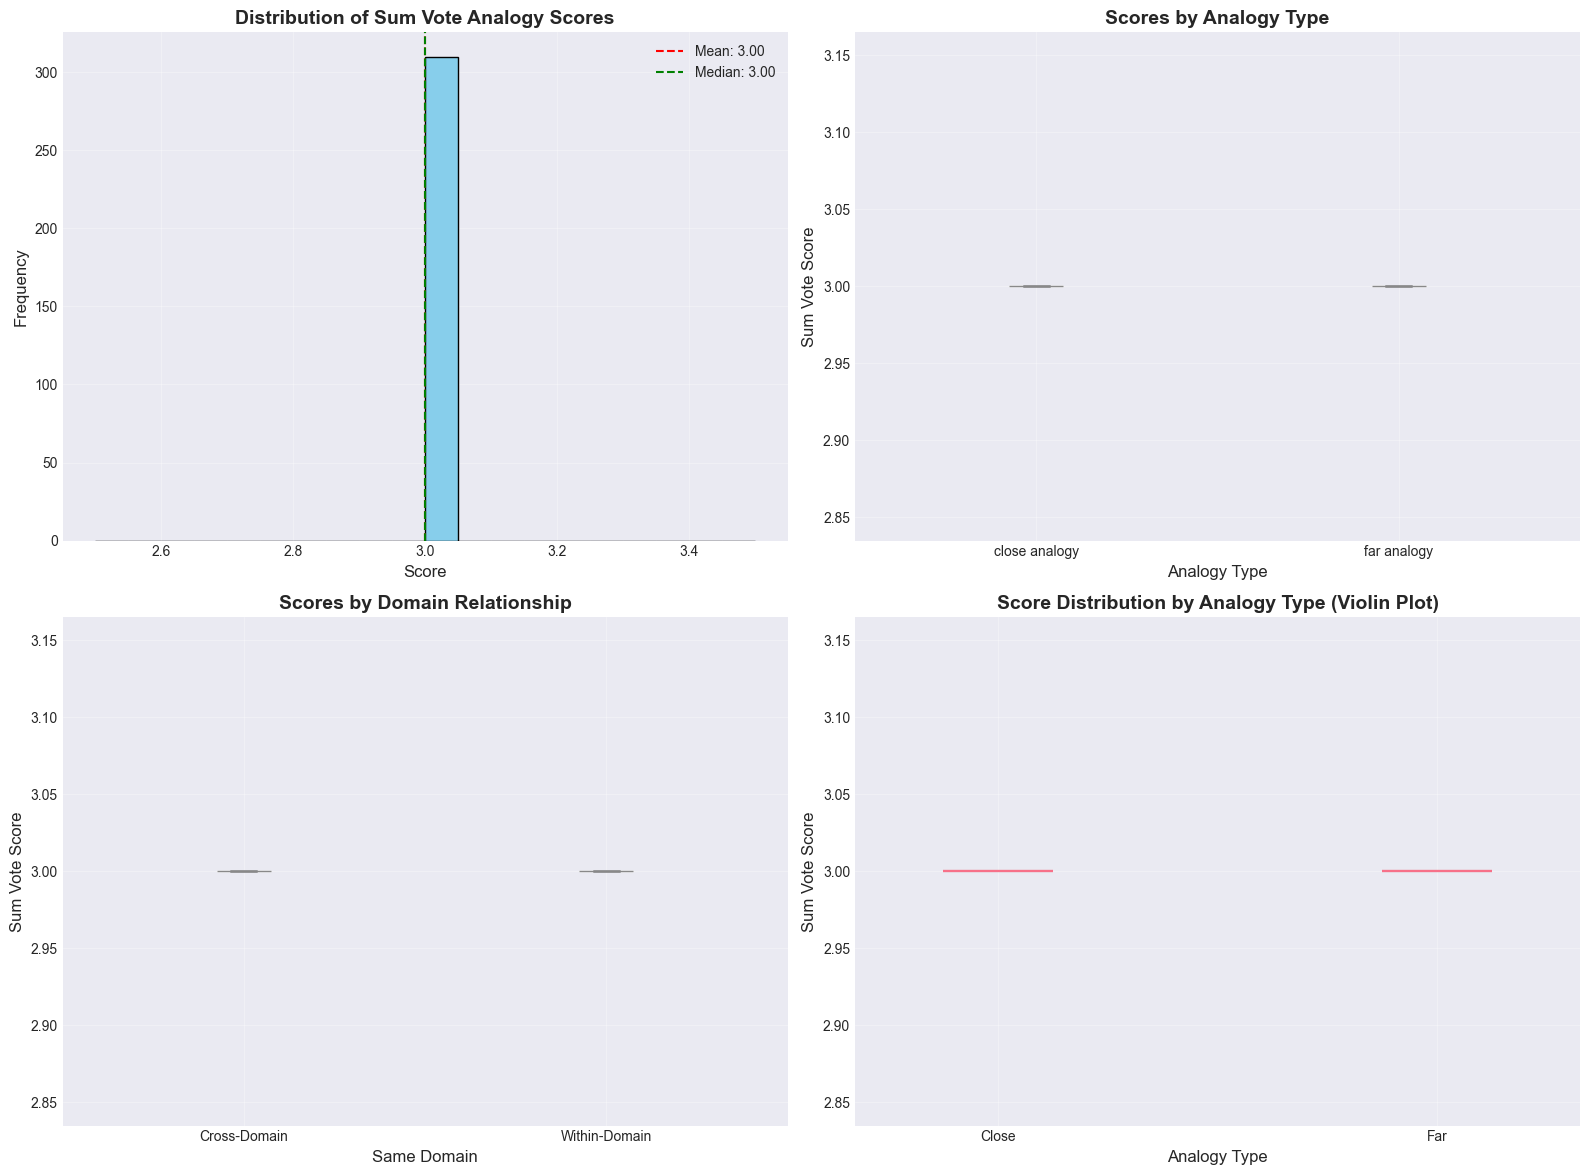

In [7]:
# Score distribution
print("Sum Vote Analogy Score Statistics:")
print(df['sum_vote_analogy'].describe())

print("\n" + "="*80 + "\n")

print("Score Distribution:")
score_dist = df['sum_vote_analogy'].value_counts().sort_index()
print(score_dist)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of scores
axes[0, 0].hist(df['sum_vote_analogy'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Sum Vote Analogy Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(df['sum_vote_analogy'].mean(), color='red', linestyle='--', label=f"Mean: {df['sum_vote_analogy'].mean():.2f}")
axes[0, 0].axvline(df['sum_vote_analogy'].median(), color='green', linestyle='--', label=f"Median: {df['sum_vote_analogy'].median():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot by analogy type
df.boxplot(column='sum_vote_analogy', by='analogy_type', ax=axes[0, 1])
axes[0, 1].set_title('Scores by Analogy Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Analogy Type', fontsize=12)
axes[0, 1].set_ylabel('Sum Vote Score', fontsize=12)
axes[0, 1].get_figure().suptitle('')
axes[0, 1].grid(alpha=0.3)

# Box plot by domain relationship
df.boxplot(column='sum_vote_analogy', by='same_domain', ax=axes[1, 0])
axes[1, 0].set_title('Scores by Domain Relationship', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Same Domain', fontsize=12)
axes[1, 0].set_ylabel('Sum Vote Score', fontsize=12)
axes[1, 0].set_xticklabels(['Cross-Domain', 'Within-Domain'])
axes[1, 0].get_figure().suptitle('')
axes[1, 0].grid(alpha=0.3)

# Violin plot by analogy type
parts = axes[1, 1].violinplot([df[df['analogy_type'] == 'close analogy']['sum_vote_analogy'].dropna(),
                                df[df['analogy_type'] == 'far analogy']['sum_vote_analogy'].dropna()],
                               positions=[1, 2], showmeans=True, showmedians=True)
axes[1, 1].set_title('Score Distribution by Analogy Type (Violin Plot)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Analogy Type', fontsize=12)
axes[1, 1].set_ylabel('Sum Vote Score', fontsize=12)
axes[1, 1].set_xticks([1, 2])
axes[1, 1].set_xticklabels(['Close', 'Far'])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# Average scores by analogy type
print("Average Scores by Analogy Type:")
avg_by_type = df.groupby('analogy_type')['sum_vote_analogy'].agg(['mean', 'median', 'std', 'count'])
print(avg_by_type)

print("\n" + "="*80 + "\n")

# Average scores by domain relationship
print("Average Scores by Domain Relationship:")
avg_by_domain_rel = df.groupby('same_domain')['sum_vote_analogy'].agg(['mean', 'median', 'std', 'count'])
avg_by_domain_rel.index = ['Cross-Domain', 'Within-Domain']
print(avg_by_domain_rel)

print("\n" + "="*80 + "\n")

# Top domain pairs by average score
print("Top 15 Domain Pairs by Average Score (min 3 samples):")
domain_pair_scores = df.groupby(['source_domain', 'target_domain']).agg({
    'sum_vote_analogy': ['mean', 'count']
}).reset_index()
domain_pair_scores.columns = ['source_domain', 'target_domain', 'avg_score', 'count']
domain_pair_scores = domain_pair_scores[domain_pair_scores['count'] >= 3]
domain_pair_scores = domain_pair_scores.sort_values('avg_score', ascending=False)
print(domain_pair_scores.head(15))


Average Scores by Analogy Type:
               mean  median  std  count
analogy_type                           
close analogy   3.0     3.0  0.0    186
far analogy     3.0     3.0  0.0    124


Average Scores by Domain Relationship:
               mean  median  std  count
Cross-Domain    3.0     3.0  0.0    196
Within-Domain   3.0     3.0  0.0    114


Top 15 Domain Pairs by Average Score (min 3 samples):
                     source_domain                   target_domain  avg_score  \
0   Biomedical and Health Sciences  Biomedical and Health Sciences        3.0   
1   Biomedical and Health Sciences                     Engineering        3.0   
2   Biomedical and Health Sciences                Natural Sciences        3.0   
3   Biomedical and Health Sciences                 Social Sciences        3.0   
4                      Engineering  Biomedical and Health Sciences        3.0   
5                      Engineering                     Engineering        3.0   
6                      E

## 5. Text Complexity Analysis

Analyzing paragraph lengths to understand optimal text complexity for different analogy types.


Source Paragraph Statistics:
       source_char_count  source_word_count
count         310.000000         310.000000
mean          313.712903          52.500000
std            59.686762           9.958409
min           177.000000          28.000000
25%           273.250000          45.000000
50%           312.000000          53.000000
75%           347.000000          58.000000
max           541.000000          85.000000


Target Paragraph Statistics:
       target_char_count  target_word_count
count         310.000000         310.000000
mean          322.690323          53.303226
std            57.475822           9.496294
min           198.000000          34.000000
25%           282.250000          46.000000
50%           316.000000          52.000000
75%           358.000000          59.750000
max           475.000000          80.000000


Average Character Counts:
Source: 313.7 chars
Target: 322.7 chars

Average Word Counts:
Source: 52.5 words
Target: 53.3 words


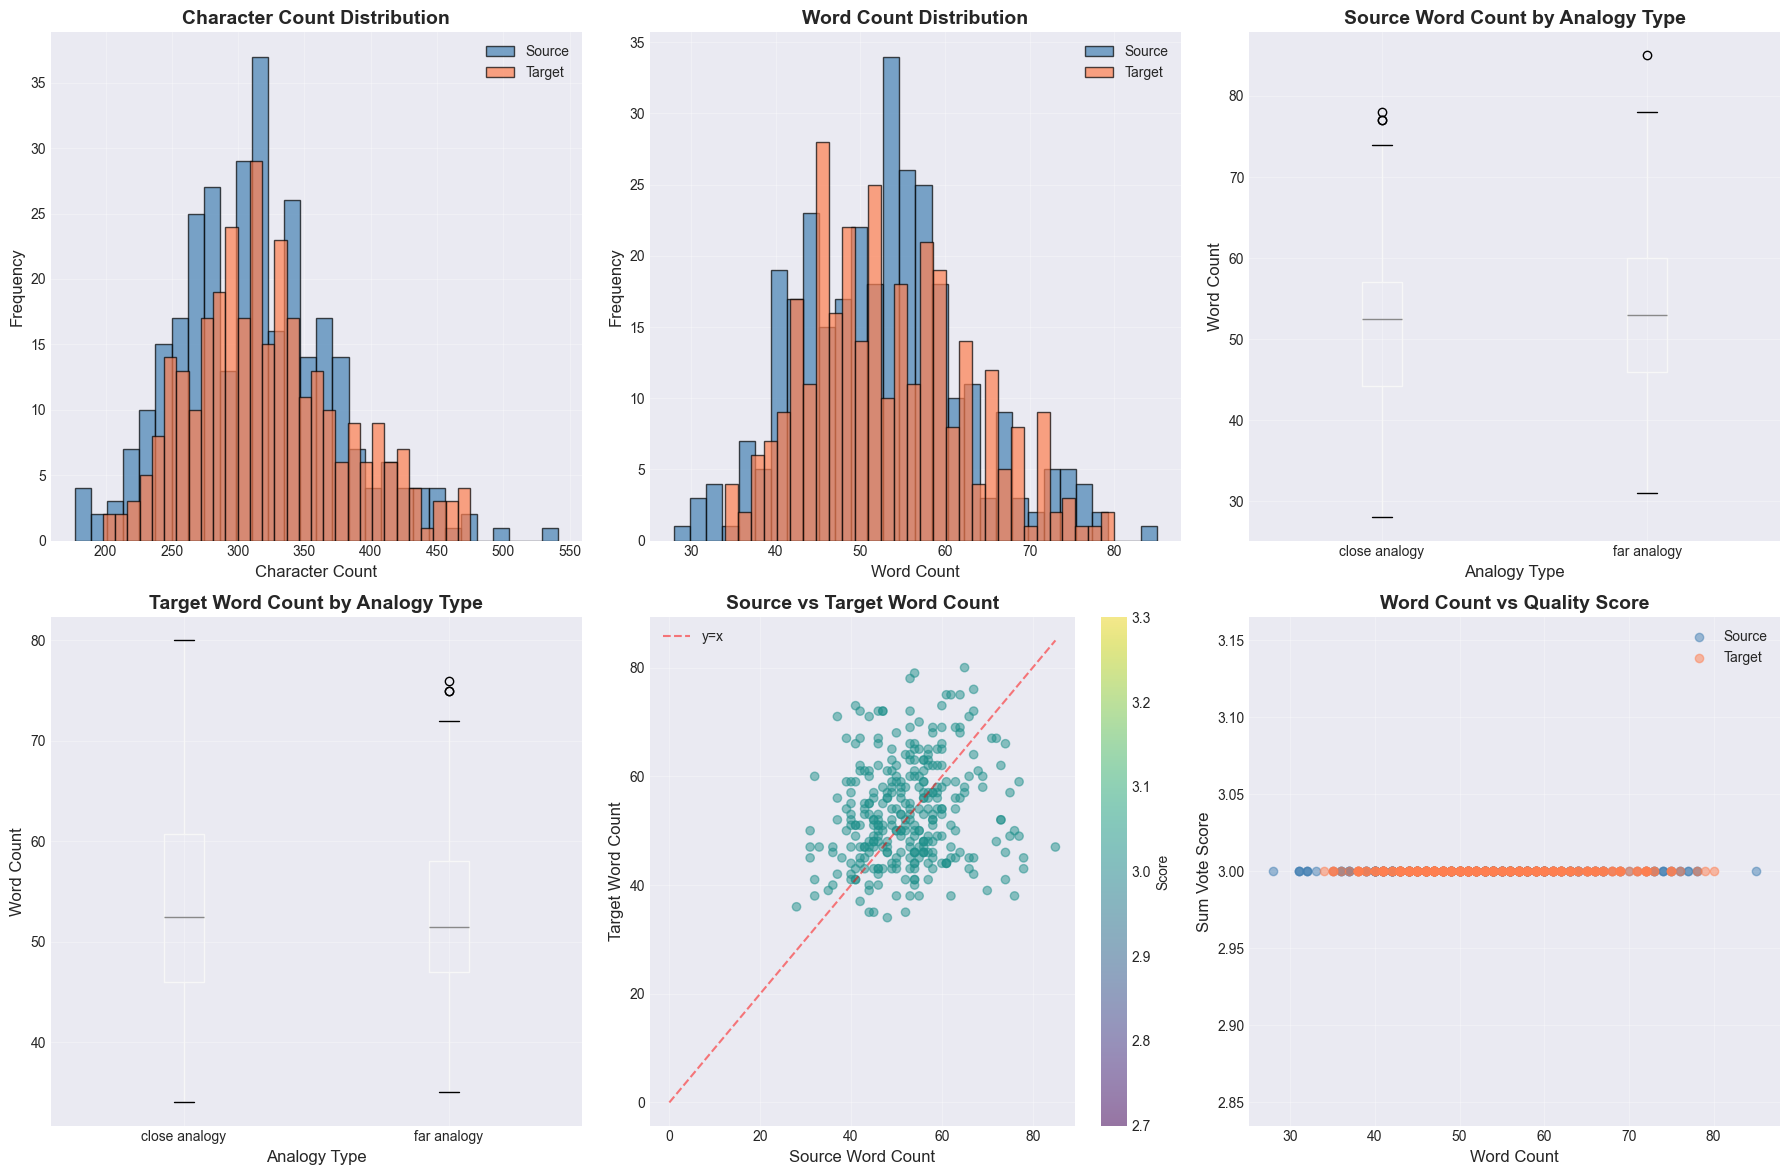

In [9]:
# Calculate text metrics
df['source_char_count'] = df['source_paragraph'].astype(str).apply(len)
df['target_char_count'] = df['target_paragraph'].astype(str).apply(len)
df['source_word_count'] = df['source_paragraph'].astype(str).apply(lambda x: len(x.split()))
df['target_word_count'] = df['target_paragraph'].astype(str).apply(lambda x: len(x.split()))

print("Source Paragraph Statistics:")
print(df[['source_char_count', 'source_word_count']].describe())

print("\n" + "="*80 + "\n")

print("Target Paragraph Statistics:")
print(df[['target_char_count', 'target_word_count']].describe())

print("\n" + "="*80 + "\n")

# Compare source vs target
print("Average Character Counts:")
print(f"Source: {df['source_char_count'].mean():.1f} chars")
print(f"Target: {df['target_char_count'].mean():.1f} chars")

print("\nAverage Word Counts:")
print(f"Source: {df['source_word_count'].mean():.1f} words")
print(f"Target: {df['target_word_count'].mean():.1f} words")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histograms
axes[0, 0].hist(df['source_char_count'], bins=30, color='steelblue', alpha=0.7, label='Source', edgecolor='black')
axes[0, 0].hist(df['target_char_count'], bins=30, color='coral', alpha=0.7, label='Target', edgecolor='black')
axes[0, 0].set_title('Character Count Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Character Count', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['source_word_count'], bins=30, color='steelblue', alpha=0.7, label='Source', edgecolor='black')
axes[0, 1].hist(df['target_word_count'], bins=30, color='coral', alpha=0.7, label='Target', edgecolor='black')
axes[0, 1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plots by analogy type
df.boxplot(column='source_word_count', by='analogy_type', ax=axes[0, 2])
axes[0, 2].set_title('Source Word Count by Analogy Type', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Analogy Type', fontsize=12)
axes[0, 2].set_ylabel('Word Count', fontsize=12)
axes[0, 2].get_figure().suptitle('')
axes[0, 2].grid(alpha=0.3)

df.boxplot(column='target_word_count', by='analogy_type', ax=axes[1, 0])
axes[1, 0].set_title('Target Word Count by Analogy Type', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Analogy Type', fontsize=12)
axes[1, 0].set_ylabel('Word Count', fontsize=12)
axes[1, 0].get_figure().suptitle('')
axes[1, 0].grid(alpha=0.3)

# Scatter plot: source vs target length
axes[1, 1].scatter(df['source_word_count'], df['target_word_count'], alpha=0.5, c=df['sum_vote_analogy'], cmap='viridis')
axes[1, 1].set_title('Source vs Target Word Count', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Source Word Count', fontsize=12)
axes[1, 1].set_ylabel('Target Word Count', fontsize=12)
axes[1, 1].plot([0, df['source_word_count'].max()], [0, df['source_word_count'].max()], 'r--', alpha=0.5, label='y=x')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Score', fontsize=10)

# Scatter: word count vs score
axes[1, 2].scatter(df['source_word_count'], df['sum_vote_analogy'], alpha=0.5, label='Source', color='steelblue')
axes[1, 2].scatter(df['target_word_count'], df['sum_vote_analogy'], alpha=0.5, label='Target', color='coral')
axes[1, 2].set_title('Word Count vs Quality Score', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Word Count', fontsize=12)
axes[1, 2].set_ylabel('Sum Vote Score', fontsize=12)
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# Correlation analysis
print("Correlation with Quality Score:")
correlations = df[['source_char_count', 'target_char_count', 'source_word_count', 'target_word_count', 'sum_vote_analogy']].corr()['sum_vote_analogy'].sort_values(ascending=False)
print(correlations)

print("\n" + "="*80 + "\n")

# Text length by analogy type
print("Average Word Counts by Analogy Type:")
length_by_type = df.groupby('analogy_type')[['source_word_count', 'target_word_count']].mean()
print(length_by_type)


Correlation with Quality Score:
source_char_count   NaN
target_char_count   NaN
source_word_count   NaN
target_word_count   NaN
sum_vote_analogy    NaN
Name: sum_vote_analogy, dtype: float64


Average Word Counts by Analogy Type:
               source_word_count  target_word_count
analogy_type                                       
close analogy          51.602151          53.505376
far analogy            53.846774          53.000000


## 6. Mapping and Relations Structure Analysis


In [11]:
# Parse relations to count triplets
def count_triplets(relations_str):
    """Count the number of relation triplets in the relations column."""
    if pd.isna(relations_str):
        return 0
    # Count occurrences of " like " which separates source and target triplets
    return relations_str.count(' like ')

df['num_triplets'] = df['relations'].apply(count_triplets)

print("Number of Relation Triplets Statistics:")
print(df['num_triplets'].describe())

print("\n" + "="*80 + "\n")

print("Distribution of Triplet Counts:")
triplet_dist = df['num_triplets'].value_counts().sort_index()
print(triplet_dist)

# Extract verbs/predicates from relations
def extract_verbs(relations_str):
    """Extract verbs (predicates) from relation triplets."""
    if pd.isna(relations_str):
        return []
    # Pattern: (entity, VERB, entity)
    pattern = r'\(([^,]+),\s*([^,]+),\s*([^)]+)\)'
    matches = re.findall(pattern, relations_str)
    # Return the middle element (verb) from each match
    return [match[1].strip() for match in matches]

all_verbs = []
for relations in df['relations']:
    all_verbs.extend(extract_verbs(relations))

print("\n" + "="*80 + "\n")
print(f"Total verbs extracted: {len(all_verbs)}")
print(f"Unique verbs: {len(set(all_verbs))}")

print("\n" + "="*80 + "\n")
print("Top 30 Most Common Verbs in Relations:")
verb_counts = Counter(all_verbs)
for verb, count in verb_counts.most_common(30):
    print(f"{verb}: {count}")


Number of Relation Triplets Statistics:
count    310.000000
mean       3.064516
std        0.258885
min        3.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        5.000000
Name: num_triplets, dtype: float64


Distribution of Triplet Counts:
num_triplets
3    291
4     18
5      1
Name: count, dtype: int64


Total verbs extracted: 1899
Unique verbs: 424


Top 30 Most Common Verbs in Relations:
absorb: 52
produces: 49
transport: 36
erodes: 29
carries: 28
creates: 22
develops: 22
absorbs: 22
carry: 22
releases: 21
exchange: 21
rises: 20
enters: 20
reproduces: 20
breaks down: 18
provides: 18
causes: 17
emit: 17
invade: 17
produce: 17
transports: 16
filters: 16
collects: 16
release: 15
converts: 14
cause: 14
expel: 13
take in: 13
hatches: 13
matures: 13


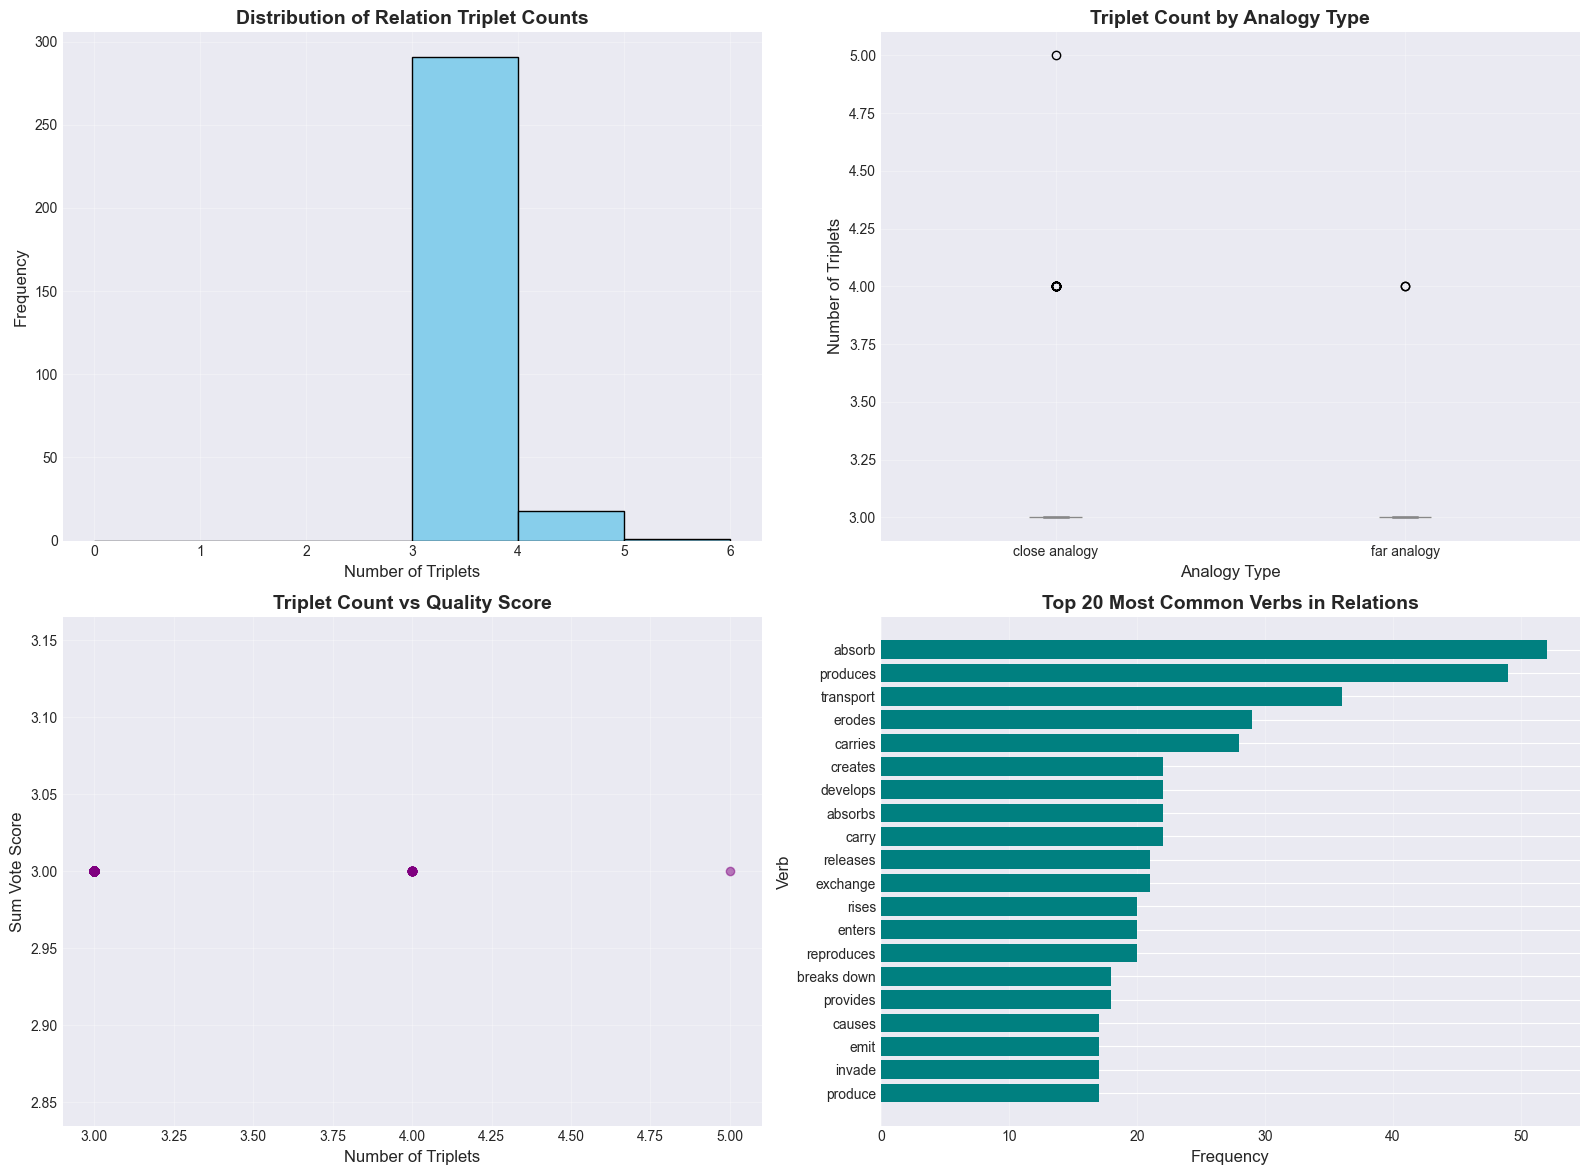



Correlation between triplet count and quality score:
Pearson correlation: nan


In [12]:
# Visualizations for mapping analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of triplet counts
axes[0, 0].hist(df['num_triplets'], bins=range(0, df['num_triplets'].max()+2), color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Relation Triplet Counts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Triplets', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(alpha=0.3)

# Triplet count by analogy type
df.boxplot(column='num_triplets', by='analogy_type', ax=axes[0, 1])
axes[0, 1].set_title('Triplet Count by Analogy Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Analogy Type', fontsize=12)
axes[0, 1].set_ylabel('Number of Triplets', fontsize=12)
axes[0, 1].get_figure().suptitle('')
axes[0, 1].grid(alpha=0.3)

# Triplet count vs quality score
axes[1, 0].scatter(df['num_triplets'], df['sum_vote_analogy'], alpha=0.5, color='purple')
axes[1, 0].set_title('Triplet Count vs Quality Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Triplets', fontsize=12)
axes[1, 0].set_ylabel('Sum Vote Score', fontsize=12)
axes[1, 0].grid(alpha=0.3)

# Top verbs bar chart
top_verbs = verb_counts.most_common(20)
verbs, counts = zip(*top_verbs)
axes[1, 1].barh(range(len(verbs)), counts, color='teal')
axes[1, 1].set_yticks(range(len(verbs)))
axes[1, 1].set_yticklabels(verbs)
axes[1, 1].set_title('Top 20 Most Common Verbs in Relations', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Frequency', fontsize=12)
axes[1, 1].set_ylabel('Verb', fontsize=12)
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation
print("\n" + "="*80 + "\n")
print("Correlation between triplet count and quality score:")
correlation = df['num_triplets'].corr(df['sum_vote_analogy'])
print(f"Pearson correlation: {correlation:.3f}")


## 7. Source Reuse and Versatility Analysis

Identifying which source concepts are most versatile for analogy generation.


In [13]:
# Source versatility analysis
source_versatility = df.groupby('source_subject').agg({
    'target_subject': 'count',
    'target_domain': 'nunique',
    'analogy_type': lambda x: (x == 'far analogy').sum(),
    'sum_vote_analogy': 'mean'
}).rename(columns={
    'target_subject': 'total_analogies',
    'target_domain': 'unique_target_domains',
    'analogy_type': 'far_analogies',
    'sum_vote_analogy': 'avg_score'
})

source_versatility = source_versatility.sort_values('total_analogies', ascending=False)

print("Top 20 Most Versatile Source Concepts:")
print(source_versatility.head(20))

print("\n" + "="*80 + "\n")

# Sources that work for both close and far analogies
both_types = df.groupby('source_subject')['analogy_type'].apply(lambda x: x.nunique() == 2)
sources_both_types = both_types[both_types].index.tolist()
print(f"Sources that work for BOTH close and far analogies: {len(sources_both_types)}")
print(f"\nTop examples:")
for source in sources_both_types[:10]:
    print(f"  - {source}")

print("\n" + "="*80 + "\n")

# Top sources by average score
top_by_score = source_versatility[source_versatility['total_analogies'] >= 3].sort_values('avg_score', ascending=False)
print("Top 15 Source Concepts by Average Score (min 3 analogies):")
print(top_by_score.head(15))


Top 20 Most Versatile Source Concepts:
                                                    total_analogies  \
source_subject                                                        
Describe how bacteria can cause disease.                          9   
Describe how oxygen reaches cells in the body                     8   
How do minerals form?                                             8   
Describe the process of desalination                              8   
How does oil get from the ground to a gas station?                7   
How do bats use echolocation?                                     7   
How do caverns form?                                              7   
How do the lungs work?                                            6   
Describe the life cycle of a frog                                 6   
How do plants use animals to help disburse thei...                6   
How are ravines formed?                                           6   
Describe how forest fires can negative

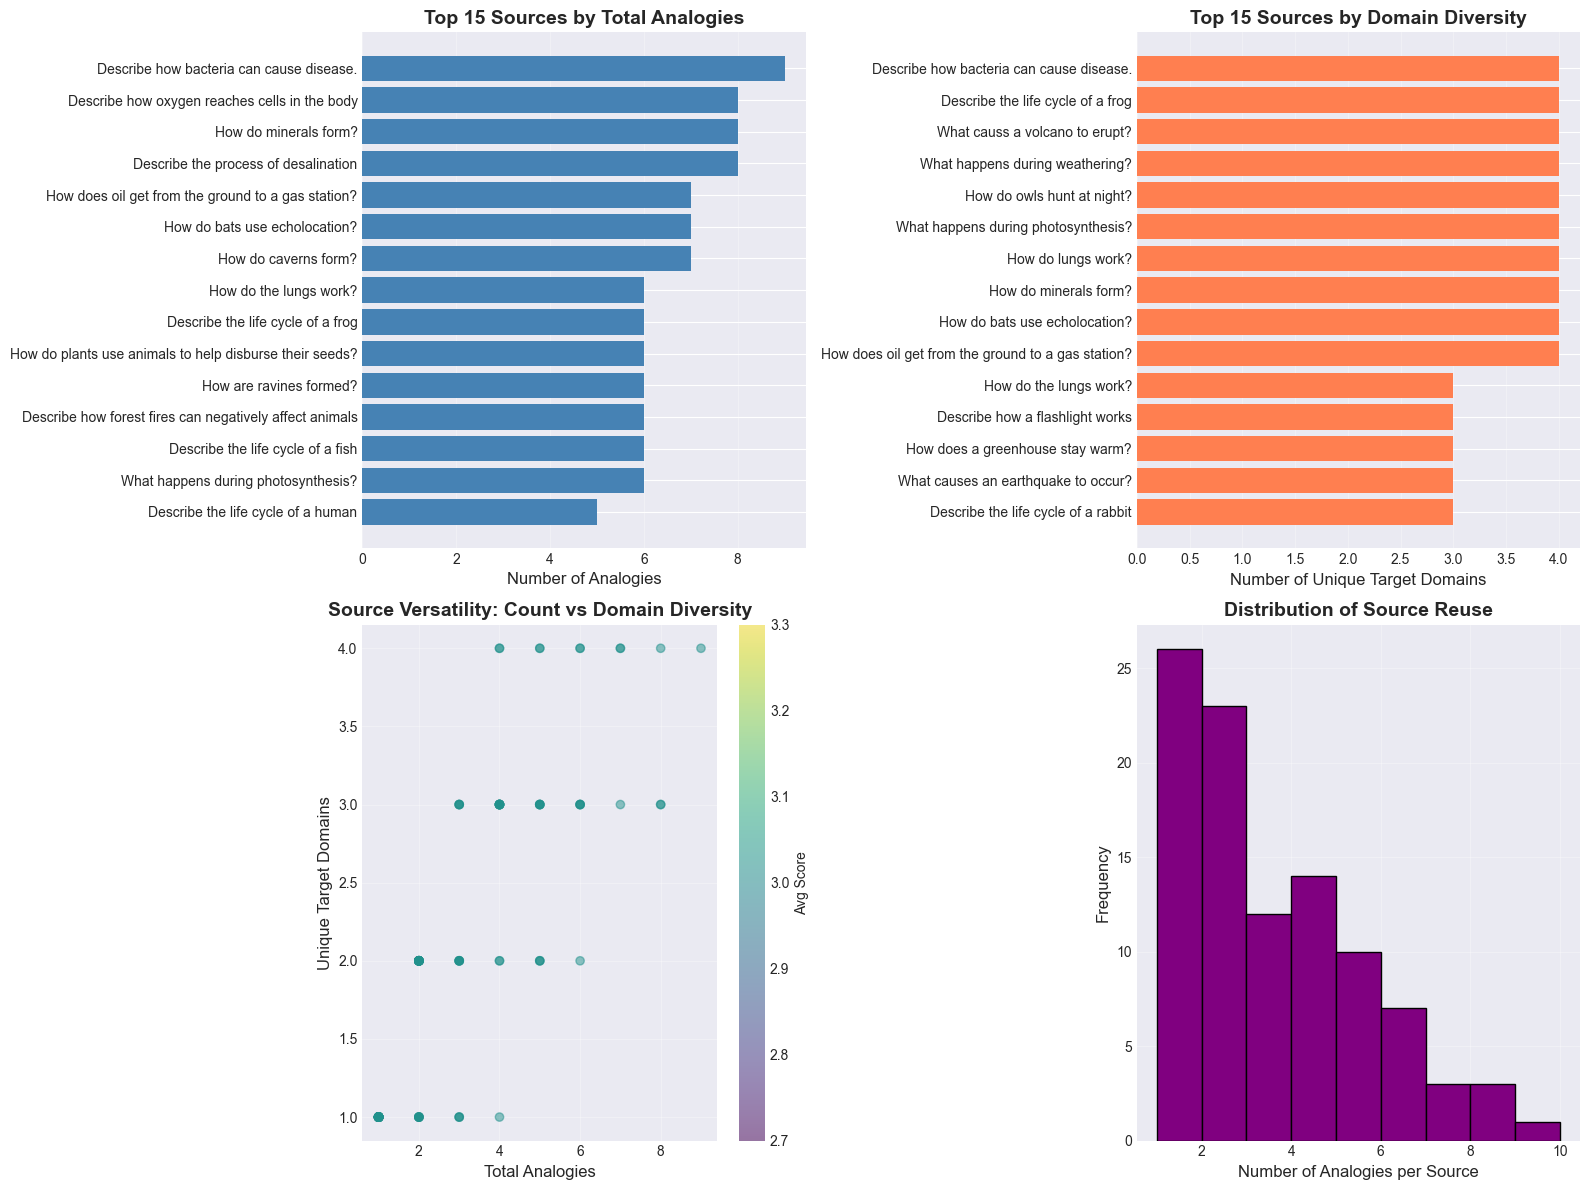

In [14]:
# Visualizations for source versatility
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top sources by total analogies
top_sources = source_versatility.head(15)
axes[0, 0].barh(range(len(top_sources)), top_sources['total_analogies'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_sources)))
axes[0, 0].set_yticklabels(top_sources.index, fontsize=10)
axes[0, 0].set_title('Top 15 Sources by Total Analogies', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Analogies', fontsize=12)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Top sources by unique target domains
top_by_domains = source_versatility.sort_values('unique_target_domains', ascending=False).head(15)
axes[0, 1].barh(range(len(top_by_domains)), top_by_domains['unique_target_domains'], color='coral')
axes[0, 1].set_yticks(range(len(top_by_domains)))
axes[0, 1].set_yticklabels(top_by_domains.index, fontsize=10)
axes[0, 1].set_title('Top 15 Sources by Domain Diversity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Unique Target Domains', fontsize=12)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Scatter: total analogies vs domain diversity
axes[1, 0].scatter(source_versatility['total_analogies'], 
                   source_versatility['unique_target_domains'], 
                   alpha=0.5, c=source_versatility['avg_score'], cmap='viridis')
axes[1, 0].set_title('Source Versatility: Count vs Domain Diversity', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total Analogies', fontsize=12)
axes[1, 0].set_ylabel('Unique Target Domains', fontsize=12)
axes[1, 0].grid(alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Avg Score', fontsize=10)

# Distribution of source reuse
reuse_counts = source_versatility['total_analogies']
axes[1, 1].hist(reuse_counts, bins=range(1, min(reuse_counts.max()+2, 20)), color='purple', edgecolor='black')
axes[1, 1].set_title('Distribution of Source Reuse', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Analogies per Source', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Field-Level Granularity Analysis

Exploring the target field distribution to understand domain sub-categories.


In [15]:
# Target field distribution
print("Target Field Distribution:")
field_dist = df['target_field'].value_counts()
print(f"Unique target fields: {df['target_field'].nunique()}")
print(f"\nTop 30 fields:")
print(field_dist.head(30))

print("\n" + "="*80 + "\n")

# Fields within each domain
print("Fields per Target Domain:")
fields_per_domain = df.groupby('target_domain')['target_field'].agg(['nunique', 'count'])
fields_per_domain.columns = ['unique_fields', 'total_analogies']
print(fields_per_domain.sort_values('unique_fields', ascending=False))

print("\n" + "="*80 + "\n")

# Average scores by field (for fields with at least 3 samples)
field_scores = df.groupby('target_field').agg({
    'sum_vote_analogy': ['mean', 'count']
}).reset_index()
field_scores.columns = ['target_field', 'avg_score', 'count']
field_scores = field_scores[field_scores['count'] >= 3].sort_values('avg_score', ascending=False)
print("Top 15 Target Fields by Average Score (min 3 samples):")
print(field_scores.head(15))


Target Field Distribution:
Unique target fields: 68

Top 30 fields:
target_field
Biomedical and Health Sciences    45
Social Sciences                   27
Geology                           21
Mechanical Engineering            20
Biology                           14
Microbiology                      12
Natural Sciences                  11
Ecology                           11
Civil Engineering                  9
Meteorology                        8
Entomology                         8
Environmental Engineering          8
Marine Biology                     7
Chemical Engineering               6
Environmental Science              6
Plant Biology                      6
Hydrology                          6
Electrical Engineering             5
Zoology                            5
Atmospheric Science                4
Petroleum Engineering              4
Botany                             3
Sociology                          3
Robotics Engineering               3
Environmental Sciences         

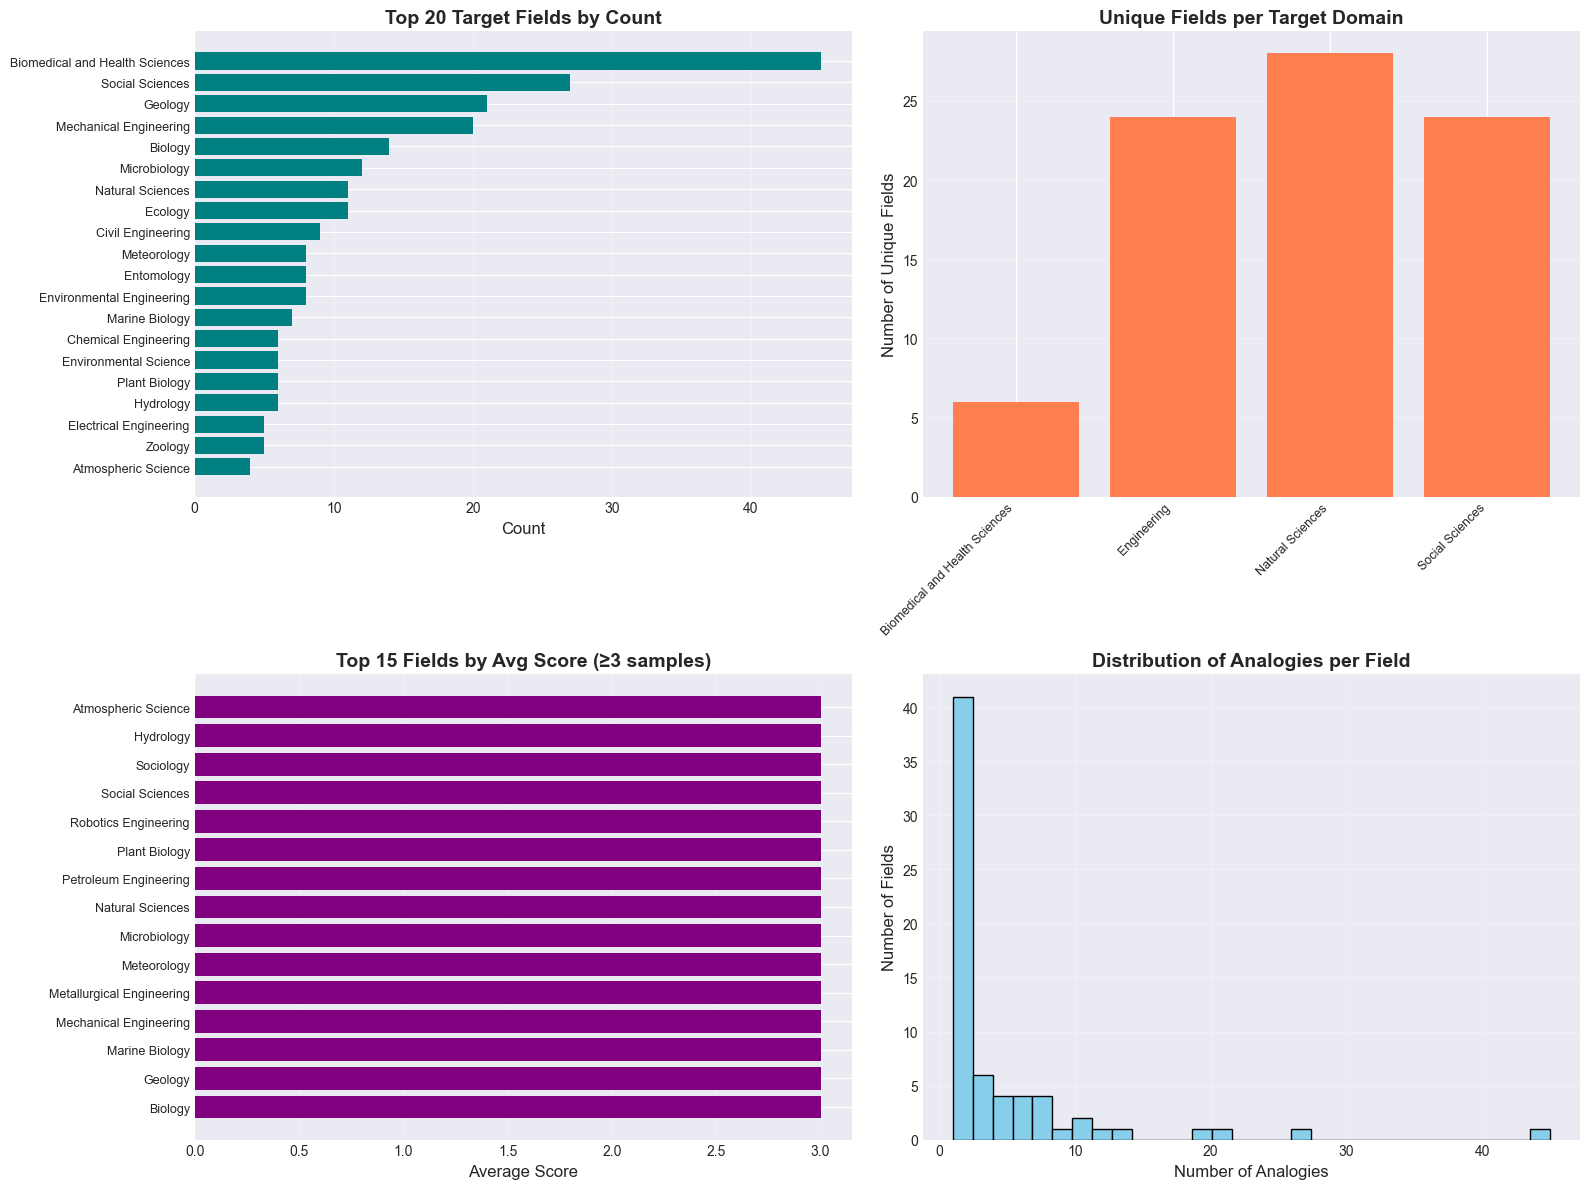

In [16]:
# Visualizations for field analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top fields by count
top_fields = field_dist.head(20)
axes[0, 0].barh(range(len(top_fields)), top_fields.values, color='teal')
axes[0, 0].set_yticks(range(len(top_fields)))
axes[0, 0].set_yticklabels(top_fields.index, fontsize=9)
axes[0, 0].set_title('Top 20 Target Fields by Count', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Count', fontsize=12)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Fields per domain
axes[0, 1].bar(range(len(fields_per_domain)), fields_per_domain['unique_fields'], color='coral')
axes[0, 1].set_xticks(range(len(fields_per_domain)))
axes[0, 1].set_xticklabels(fields_per_domain.index, rotation=45, ha='right', fontsize=9)
axes[0, 1].set_title('Unique Fields per Target Domain', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Unique Fields', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Top fields by average score
top_field_scores = field_scores.head(15)
axes[1, 0].barh(range(len(top_field_scores)), top_field_scores['avg_score'], color='purple')
axes[1, 0].set_yticks(range(len(top_field_scores)))
axes[1, 0].set_yticklabels(top_field_scores['target_field'], fontsize=9)
axes[1, 0].set_title('Top 15 Fields by Avg Score (≥3 samples)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Score', fontsize=12)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Field count distribution
field_counts = field_dist.values
axes[1, 1].hist(field_counts, bins=30, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Distribution of Analogies per Field', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Analogies', fontsize=12)
axes[1, 1].set_ylabel('Number of Fields', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Key Insights for Model Development

Synthesizing all findings into actionable insights for analogy generation pipeline.


In [17]:
print("="*100)
print("ACTIONABLE INSIGHTS FOR ANALOGY GENERATION MODELS")
print("="*100)

print("\n### 1. SOURCE SELECTION STRATEGY ###\n")
print(f"✓ Total unique source concepts: {df['source_subject'].nunique()}")
print(f"✓ Average reuse per source: {source_versatility['total_analogies'].mean():.1f} analogies")
print(f"✓ Most versatile source (by count): {source_versatility.index[0]} ({source_versatility.iloc[0]['total_analogies']:.0f} analogies)")
print(f"✓ Most versatile source (by domains): {source_versatility.sort_values('unique_target_domains', ascending=False).index[0]}")
print(f"✓ Sources working for both close AND far analogies: {len(sources_both_types)}")
print("\n📌 RECOMMENDATION: Prioritize sources from Natural Sciences domain that can span multiple target domains")

print("\n" + "-"*100)

print("\n### 2. DOMAIN MAPPING PATTERNS ###\n")
print(f"✓ Within-domain analogies: {within_domain} ({within_domain/len(df)*100:.1f}%)")
print(f"✓ Cross-domain analogies: {cross_domain} ({cross_domain/len(df)*100:.1f}%)")
print(f"✓ Close analogies tend to be: {'within-domain' if analogy_domain_cross.loc['close analogy', True] > 50 else 'cross-domain'}")
print(f"✓ Far analogies tend to be: {'cross-domain' if analogy_domain_cross.loc['far analogy', False] > 50 else 'within-domain'}")
top_pair = domain_pairs_sorted.iloc[0]
print(f"✓ Most common domain pair: {top_pair['source_domain']} → {top_pair['target_domain']} ({top_pair['count']} analogies)")
print("\n📌 RECOMMENDATION: Close analogies should stay within same domain; far analogies should cross domains")

print("\n" + "-"*100)

print("\n### 3. MAPPING GENERATION (Relations/Triplets) ###\n")
print(f"✓ Average triplets per analogy: {df['num_triplets'].mean():.1f}")
print(f"✓ Median triplets: {df['num_triplets'].median():.0f}")
print(f"✓ Most common triplet count: {df['num_triplets'].mode().values[0]:.0f}")
print(f"✓ Correlation with quality: {df['num_triplets'].corr(df['sum_vote_analogy']):.3f}")
print(f"✓ Most common verbs: {', '.join([v for v, c in verb_counts.most_common(5)])}")
print(f"✓ Total unique verbs used: {len(set(all_verbs))}")
print("\n📌 RECOMMENDATION: Target 3 relation triplets per analogy; use action verbs (builds, creates, causes)")

print("\n" + "-"*100)

print("\n### 4. EXPLANATION QUALITY (Text Length) ###\n")
print(f"✓ Average source paragraph: {df['source_word_count'].mean():.0f} words ({df['source_char_count'].mean():.0f} chars)")
print(f"✓ Average target paragraph: {df['target_word_count'].mean():.0f} words ({df['target_char_count'].mean():.0f} chars)")
print(f"✓ Correlation (source length vs score): {df['source_word_count'].corr(df['sum_vote_analogy']):.3f}")
print(f"✓ Correlation (target length vs score): {df['target_word_count'].corr(df['sum_vote_analogy']):.3f}")
close_avg = df[df['analogy_type']=='close analogy']['source_word_count'].mean()
far_avg = df[df['analogy_type']=='far analogy']['source_word_count'].mean()
print(f"✓ Close analogies avg length: {close_avg:.0f} words")
print(f"✓ Far analogies avg length: {far_avg:.0f} words")
print("\n📌 RECOMMENDATION: Keep explanations between 50-70 words; longer paragraphs don't improve quality")

print("\n" + "-"*100)

print("\n### 5. QUALITY SCORES PATTERNS ###\n")
print(f"✓ Mean quality score: {df['sum_vote_analogy'].mean():.2f}")
print(f"✓ Median quality score: {df['sum_vote_analogy'].median():.2f}")
print(f"✓ Close analogy avg score: {df[df['analogy_type']=='close analogy']['sum_vote_analogy'].mean():.2f}")
print(f"✓ Far analogy avg score: {df[df['analogy_type']=='far analogy']['sum_vote_analogy'].mean():.2f}")
print(f"✓ Within-domain avg score: {df[df['same_domain']==True]['sum_vote_analogy'].mean():.2f}")
print(f"✓ Cross-domain avg score: {df[df['same_domain']==False]['sum_vote_analogy'].mean():.2f}")
if len(domain_pair_scores) > 0:
    best_pair = domain_pair_scores.iloc[0]
    print(f"✓ Best domain pair: {best_pair['source_domain']} → {best_pair['target_domain']} (avg: {best_pair['avg_score']:.2f})")
print("\n📌 RECOMMENDATION: Both close and far analogies achieve similar quality; focus on appropriate domain mapping")

print("\n" + "-"*100)

print("\n### 6. DATASET CHARACTERISTICS ###\n")
print(f"✓ Total analogies: {len(df)}")
print(f"✓ Unique source concepts: {df['source_subject'].nunique()}")
print(f"✓ Unique target concepts: {df['target_subject'].nunique()}")
print(f"✓ Source domains: {df['source_domain'].nunique()}")
print(f"✓ Target domains: {df['target_domain'].nunique()}")
print(f"✓ Target fields: {df['target_field'].nunique()}")
print(f"✓ Close/Far ratio: {analogy_type_dist.get('close analogy', 0)/analogy_type_dist.get('far analogy', 1):.2f}")

print("\n" + "="*100)
print("END OF INSIGHTS SUMMARY")
print("="*100)


ACTIONABLE INSIGHTS FOR ANALOGY GENERATION MODELS

### 1. SOURCE SELECTION STRATEGY ###

✓ Total unique source concepts: 99
✓ Average reuse per source: 3.1 analogies
✓ Most versatile source (by count): Describe how bacteria can cause disease. (9 analogies)
✓ Most versatile source (by domains): Describe how bacteria can cause disease.
✓ Sources working for both close AND far analogies: 49

📌 RECOMMENDATION: Prioritize sources from Natural Sciences domain that can span multiple target domains

----------------------------------------------------------------------------------------------------

### 2. DOMAIN MAPPING PATTERNS ###

✓ Within-domain analogies: 114 (36.8%)
✓ Cross-domain analogies: 196 (63.2%)
✓ Close analogies tend to be: within-domain
✓ Far analogies tend to be: cross-domain
✓ Most common domain pair: Natural Sciences → Natural Sciences (77 analogies)

📌 RECOMMENDATION: Close analogies should stay within same domain; far analogies should cross domains

----------------------

## 10. Summary Statistics Table

Creating a comprehensive summary for quick reference.


In [18]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Total Analogies',
        'Unique Sources',
        'Unique Targets',
        'Source Domains',
        'Target Domains',
        'Target Fields',
        'Close Analogies',
        'Far Analogies',
        'Within-Domain',
        'Cross-Domain',
        'Avg Source Words',
        'Avg Target Words',
        'Avg Triplets',
        'Avg Quality Score',
        'Unique Verbs',
    ],
    'Value': [
        len(df),
        df['source_subject'].nunique(),
        df['target_subject'].nunique(),
        df['source_domain'].nunique(),
        df['target_domain'].nunique(),
        df['target_field'].nunique(),
        f"{analogy_type_dist.get('close analogy', 0)} ({analogy_type_dist.get('close analogy', 0)/len(df)*100:.1f}%)",
        f"{analogy_type_dist.get('far analogy', 0)} ({analogy_type_dist.get('far analogy', 0)/len(df)*100:.1f}%)",
        f"{within_domain} ({within_domain/len(df)*100:.1f}%)",
        f"{cross_domain} ({cross_domain/len(df)*100:.1f}%)",
        f"{df['source_word_count'].mean():.1f}",
        f"{df['target_word_count'].mean():.1f}",
        f"{df['num_triplets'].mean():.1f}",
        f"{df['sum_vote_analogy'].mean():.2f}",
        len(set(all_verbs)),
    ]
}

summary_df = pd.DataFrame(summary_data)
print("PARALLEL_PARC Dataset Summary")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


PARALLEL_PARC Dataset Summary
           Metric       Value
  Total Analogies         310
   Unique Sources          99
   Unique Targets         288
   Source Domains           4
   Target Domains           4
    Target Fields          68
  Close Analogies 186 (60.0%)
    Far Analogies 124 (40.0%)
    Within-Domain 114 (36.8%)
     Cross-Domain 196 (63.2%)
 Avg Source Words        52.5
 Avg Target Words        53.3
     Avg Triplets         3.1
Avg Quality Score        3.00
     Unique Verbs         424
